In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow

In [2]:
df=pd.read_csv("/content/ushape.csv")

In [3]:
df

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [22]:
df.columns

Index(['3.159499363321345566e-02', '9.869877579082642072e-01',
       '0.000000000000000000e+00'],
      dtype='object')

In [23]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [24]:
x

,3.159499363321345566e-02,9.869877579082642072e-01
0,2.115098,-0.046244
1,0.882490,-0.075756
2,-0.055144,-0.037332
3,0.829545,-0.539321
4,2.112857,0.662084
...,...,...
94,1.699453,0.587720
95,0.218623,-0.652521
96,0.952914,-0.419766
97,-1.318500,0.423112


In [25]:
y

,0.000000000000000000e+00
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
94,1.0
95,1.0
96,1.0
97,0.0


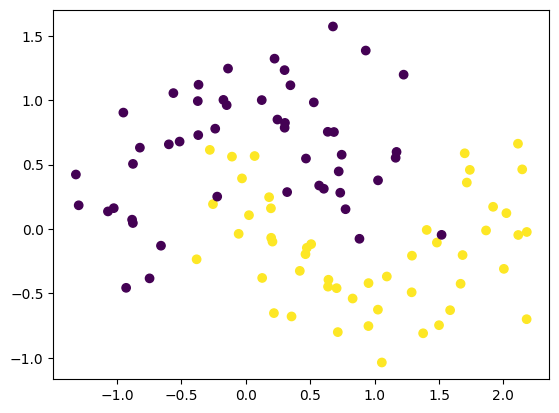

In [31]:
plt.scatter(df['3.159499363321345566e-02'],df['9.869877579082642072e-01'],c=df['0.000000000000000000e+00'])

In [9]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [11]:
model=Sequential()

model.add(Dense(10,input_dim=2,activation="tanh"))
model.add(Dense(10,activation="tanh"))
model.add(Dense(10,activation="tanh"))
model.add(Dense(10,activation="tanh"))
model.add(Dense(1,activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print(model)

<Sequential name=sequential_1, built=True>


In [14]:
model.get_weights()

[array([[ 0.44540387, -0.3307597 , -0.21514955, -0.22109967, -0.40444013,
         -0.6516734 ,  0.19621903, -0.46270257, -0.0055809 ,  0.6871211 ],
        [-0.10510445, -0.4438348 ,  0.25602067, -0.52018905, -0.53466666,
         -0.6374636 ,  0.5056786 , -0.24917856, -0.15412915,  0.55552584]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.31313485,  0.2537796 , -0.31469214, -0.30179363,  0.33734274,
         -0.20501503,  0.47666633,  0.44317   ,  0.522205  , -0.40297705],
        [-0.42488098, -0.02987707,  0.38334   , -0.37674302,  0.4429586 ,
         -0.43804184,  0.01846373, -0.3274031 , -0.42005056,  0.2708429 ],
        [-0.16706651, -0.2651929 , -0.4096707 , -0.49421877,  0.54123974,
         -0.41927004, -0.02111948, -0.3078004 , -0.35513997,  0.16762924],
        [ 0.29606467,  0.23048872,  0.5125377 ,  0.36411655, -0.02962565,
          0.24103439, -0.2873828 , -0.08780345,  0.23898602,  0.25991172],
        [-0.35634

In [16]:
initial_weights = model.get_weights()
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [19]:
model.set_weights(initial_weights)

In [20]:
model.get_weights()

[array([[ 0.12492353, -0.78922164, -1.1315191 , -0.60089624,  0.04512378,
          0.00469135,  0.39323196,  0.36501172, -0.3238199 , -0.85034174],
        [-0.14777245,  0.35552993,  0.37444758,  0.00883596,  0.6691998 ,
         -0.08582083,  0.22127917,  0.05385768, -1.2141229 ,  0.3249535 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.14319439,  0.51849943, -0.00593201,  0.4754868 , -0.24045199,
          0.07494899, -0.05421209,  0.2543296 ,  0.07374315, -0.2513395 ],
        [-0.28464788, -0.12015198,  0.21107957,  0.72597045, -0.20012057,
          0.06822018,  0.12750353, -0.28323758,  0.11468901, -0.39335105],
        [-0.4386254 , -0.33849117, -0.46407056, -0.14670014, -0.28026733,
         -0.23338331, -0.4275321 , -0.05621612,  0.24822678, -0.17427002],
        [ 0.03696308,  0.11470511, -0.08507414, -0.07100315, -0.5691934 ,
          0.24907112,  0.00442971, -0.12130569, -0.39549962, -0.07006372],
        [ 0.16770

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x,y,epochs=30,validation_split=0.2)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7468 - loss: 0.5825 - val_accuracy: 0.8500 - val_loss: 0.5183
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7468 - loss: 0.5711 - val_accuracy: 0.8500 - val_loss: 0.5039
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7722 - loss: 0.5594 - val_accuracy: 0.8500 - val_loss: 0.4900
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7595 - loss: 0.5497 - val_accuracy: 0.8500 - val_loss: 0.4767
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7595 - loss: 0.5392 - val_accuracy: 0.8500 - val_loss: 0.4639
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7595 - loss: 0.5304 - val_accuracy: 0.8500 - val_loss: 0.4517
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7722 - loss: 0.5216 - val_accuracy: 0.8500 - val_loss: 0.4401
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7722 - loss: 0.5129 - val_accuracy: 0.8500 - val_loss: 0.4294


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 765us/step


<Axes: >

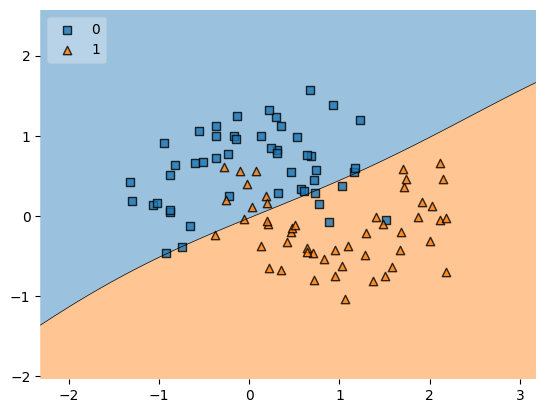

In [32]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.astype('int').to_numpy(), clf=model, legend=2)